In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

Messages:
AI Message, SystemMessage,HumanMessage and Tool Message

In [2]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages = [AIMessage(content=f"please tell me how can I help", name = "LLM Model")]
messages.append(HumanMessage(content=f"I want  to learn coding ", name = "Manoj"))
messages.append(AIMessage(content=f"which programming langudage do you want to learn ", name = "LLM Model"))
messages.append(HumanMessage(content=f"I want  to learn python coding ", name = "Manoj"))

for message in messages:
    message.pretty_print()


================================== Ai Message ==================================
Name: LLM Model

please tell me how can I help
================================ Human Message =================================
Name: Manoj

I want  to learn coding 
================================== Ai Message ==================================
Name: LLM Model

which programming langudage do you want to learn
================================ Human Message =================================
Name: Manoj

I want  to learn python coding 


In [3]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model = "gpt-4o")

from langchain_groq import ChatGroq
llm_groq = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

d:\Udemy Projects\Ai Applied Projects\Applied Ai\LC_environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
llm_groq.invoke(messages)

AIMessage(content='Python is an excellent language to learn, especially for beginners. Here\'s a step-by-step guide to help you get started:\n\n**Step 1: Get Python installed on your computer**\n\n1. Go to the official Python website: [www.python.org](http://www.python.org)\n2. Click on the "Download" button and select the correct version for your operating system (Windows, macOS, or Linux).\n3. Follow the installation instructions to install Python on your computer.\n\n**Step 2: Choose a text editor or IDE**\n\n1. A text editor or IDE (Integrated Development Environment) is where you\'ll write your Python code. Some popular choices for beginners include:\n\t* PyCharm (free community edition)\n\t* Visual Studio Code (free)\n\t* Sublime Text (free trial, then paid)\n\t* Notepad++ (free, for Windows)\n\t* TextEdit (free, for macOS)\n2. Download and install your chosen text editor or IDE.\n\n**Step 3: Learn the basics**\n\n1. Start with basic syntax and data types:\n\t* Variables (e.g., `

Tools


In [24]:
def add(a: int, b: int) -> int:
    """
    Add a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a + b

llm_with_tools = llm.bind_tools([add])

# -----------------------------
#Invoke
# -----------------------------
response = llm_with_tools.invoke(
    [HumanMessage(content="What is 2 plus 2?")]
)

print(response)




content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 60, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_92be149232', 'id': 'chatcmpl-DS9KqnIA2j7Cd25vr8Yu9EHOKFCIv', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d6a17-d3c8-7170-99be-4811d66af252-0' tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'call_6cOie3BlovR6COeV43KTBm3M', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 60, 'output_tokens': 17, 'total_tokens': 77, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [7]:
response.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'call_XFAo2KzCyMrZVgphz37qoSyN',
  'type': 'tool_call'}]

Reducers


In [8]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [9]:
initial_messages = [AIMessage(content=f"please tell me how can I help", name = "LLM Model")]
initial_messages.append(HumanMessage(content=f"I want  to learn coding ", name = "Manoj"))


In [10]:
ai_message = AIMessage(content=f"which programming langudage do you want to learn ", name = "LLM Model")


In [11]:
add_messages(initial_messages,ai_message)

[AIMessage(content='please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLM Model', id='79241799-e192-45b0-87b5-b838b7ddf1c7', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want  to learn coding ', additional_kwargs={}, response_metadata={}, name='Manoj', id='40c5e71b-21d8-4fe6-9c87-b961e3a74f52'),
 AIMessage(content='which programming langudage do you want to learn ', additional_kwargs={}, response_metadata={}, name='LLM Model', id='87e1c5ef-9607-494f-b6cd-fea4c162fff9', tool_calls=[], invalid_tool_calls=[])]

In [12]:
def llm_tool(state:State):
    return{"messages":[llm_with_tools.invoke(state["messages"])]}

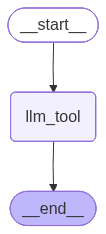

In [13]:
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

builder = StateGraph(State)
builder.add_node("llm_tool", llm_tool)
builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool", END)
graph = builder.compile()
#view the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
messages = graph.invoke({"messages":"What is 2 plus 2?"})
print(messages)
for message in messages["messages"]:
    message.pretty_print()

{'messages': [HumanMessage(content='What is 2 plus 2?', additional_kwargs={}, response_metadata={}, id='2a55b175-91c7-43c6-8bbd-58d4224c4f80'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 60, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_92be149232', 'id': 'chatcmpl-DS92tKSlZAbZNw6ck0dtxcbeiZI3e', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6a06-d8af-7952-9281-bbb9c2317ec5-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'call_K5JWOE6aY42p8nxG35a9XSXA', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 60, 'output_tokens': 17, 'total_tokens'

In [27]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

tools = [add]

builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    tools_condition
)
builder.add_edge("tools",END)
graph = builder.compile()


In [28]:
messages = graph.invoke({"messages":"What is 2 plus 2?"})
print(messages)
for message in messages["messages"]:
    message.pretty_print()

{'messages': [HumanMessage(content='What is 2 plus 2?', additional_kwargs={}, response_metadata={}, id='495189f1-6139-4f90-aee4-ef613c663966'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 60, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_92be149232', 'id': 'chatcmpl-DS9QbZJGtmp8qqeToipcylTpLjqUg', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d6a1d-432a-78b1-9232-efd67c0e7628-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'call_hop8fSBMsttCQstdZ9lQDbSB', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 60, 'output_tokens': 17, 'total_tokens'